# Query Execution Models: Iterator vs Vectorized vs JIT

**Data Mastery Lab** — Salesforce Data Cloud

---

## What we'll explore

1. **Iterator (Volcano) model** — the classical pull-based, tuple-at-a-time approach
2. **Vectorized execution** — batch-at-a-time processing with SIMD and cache locality
3. **JIT compilation** — generating native code for each query, eliminating interpretation
4. **Head-to-head benchmarks** — measuring the real difference on modern hardware

### The core insight

> The three models differ in **how much work happens per function call**
> and **how well they use modern CPU hardware** (caches, pipelines, SIMD).

| Model | Unit of work | Function calls | CPU utilization |
|-------|-------------|----------------|------------------|
| **Iterator** | 1 tuple | N × operators | Poor (cache misses, branch mispredicts) |
| **Vectorized** | ~1024 tuples | N/1024 × operators | Good (SIMD, cache-friendly loops) |
| **JIT compiled** | Full pipeline | 1 fused loop | Best (no interpretation, compiler-optimized) |

### Key references

- **Goetz Graefe, 1994** — "Volcano: An Extensible and Parallel Query Evaluation System"
- **Marcin Zukowski (CWI), 2005** — MonetDB/X100: the paper that introduced vectorized execution
- **Thomas Neumann (TU Munich), 2011** — "Efficiently Compiling Efficient Query Plans for Modern Hardware" (HyPer/Umbra)
- **CMU 15-721 (Andy Pavlo)** — Lectures on execution models, vectorization, and compilation

In [1]:
import sys, os, shutil, time, random
sys.path.insert(0, '.')
from query_viz import (render_volcano_model, render_vectorized_model,
                       render_jit_model, render_three_models_comparison,
                       render_cache_behavior)
from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = "_output"
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)
print(f"Output directory: {OUTPUT_DIR}/")

Output directory: _output/


---
## Part 1: The Iterator (Volcano) Model

Invented by Goetz Graefe (1990s). Used by PostgreSQL, MySQL, SQLite, and most traditional databases.

Every operator in the query plan implements a `next()` method:
- `next()` returns **one tuple** at a time
- Each operator **pulls** from its child by calling `child.next()`
- The root operator drives everything by repeatedly calling `next()`

```
Aggregate.next()  →  calls Filter.next()  →  calls Scan.next()
     ↑                      ↑                      ↑
   1 tuple              1 tuple               1 tuple from disk
```

**Elegant and composable.** Any operator can be plugged in anywhere.
But there's a hidden cost: **virtual function dispatch per tuple, per operator**.

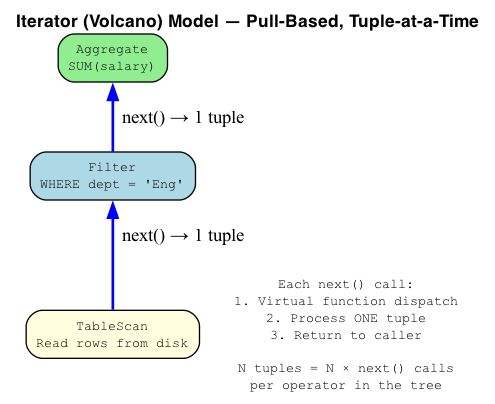

In [2]:
# Visualize the Volcano model
path = render_volcano_model(
    operators=[
        {"name": "TableScan", "description": "Read rows from disk", "color": "lightyellow"},
        {"name": "Filter", "description": "WHERE dept = 'Eng'", "color": "lightblue"},
        {"name": "Aggregate", "description": "SUM(salary)", "color": "lightgreen"},
    ],
    filename="volcano", output_dir=OUTPUT_DIR,
)
if path.endswith(".png"):
    display(Image(filename=path))

In [3]:
# Implement the iterator model in Python

class ScanOperator:
    """Reads from an in-memory table, one row at a time."""
    def __init__(self, data: dict):
        self.data = data
        self.n_rows = len(next(iter(data.values())))
        self.pos = 0
        self.calls = 0
    
    def next(self):
        self.calls += 1
        if self.pos >= self.n_rows:
            return None
        row = {col: self.data[col][self.pos] for col in self.data}
        self.pos += 1
        return row

class FilterOperator:
    """Filters rows based on a predicate."""
    def __init__(self, child, column: str, value):
        self.child = child
        self.column = column
        self.value = value
        self.calls = 0
    
    def next(self):
        self.calls += 1
        while True:
            row = self.child.next()
            if row is None:
                return None
            if row[self.column] == self.value:
                return row

class AggregateOperator:
    """Computes SUM of a column."""
    def __init__(self, child, column: str):
        self.child = child
        self.column = column
        self.calls = 0
    
    def next(self):
        self.calls += 1
        total = 0
        count = 0
        while True:
            row = self.child.next()
            if row is None:
                return {"sum": total, "count": count} if count > 0 else None
            total += row[self.column]
            count += 1

# Generate test data
N = 1_000_000
random.seed(42)
departments = ["Engineering", "Sales", "Marketing", "Finance", "HR"]
data = {
    "id": list(range(N)),
    "department": [random.choice(departments) for _ in range(N)],
    "salary": [random.randint(50000, 200000) for _ in range(N)],
}

# Query: SELECT SUM(salary) FROM employees WHERE department = 'Engineering'
print("Query: SELECT SUM(salary) WHERE department = 'Engineering'")
print(f"Data: {N:,} rows\n")

scan = ScanOperator(data)
filt = FilterOperator(scan, "department", "Engineering")
agg = AggregateOperator(filt, "salary")

start = time.time()
result = agg.next()
iterator_time = time.time() - start

print(f"Result: SUM={result['sum']:,}, COUNT={result['count']:,}")
print(f"Time: {iterator_time:.3f}s")
print(f"\nFunction calls:")
print(f"  Scan.next():      {scan.calls:>10,}")
print(f"  Filter.next():    {filt.calls:>10,}")
print(f"  Aggregate.next(): {agg.calls:>10,}")
print(f"  Total:            {scan.calls + filt.calls + agg.calls:>10,}")
print(f"\n→ {scan.calls + filt.calls + agg.calls:,} function calls for {N:,} rows.")
print(f"→ Each call has: virtual dispatch + function prologue/epilogue + potential cache miss.")
print(f"→ The actual computation (compare + add) is trivial. The overhead dominates.")

Query: SELECT SUM(salary) WHERE department = 'Engineering'
Data: 1,000,000 rows



Result: SUM=25,027,727,296, COUNT=200,387
Time: 0.270s

Function calls:
  Scan.next():       1,000,001
  Filter.next():       200,388
  Aggregate.next():          1
  Total:             1,200,390

→ 1,200,390 function calls for 1,000,000 rows.
→ Each call has: virtual dispatch + function prologue/epilogue + potential cache miss.
→ The actual computation (compare + add) is trivial. The overhead dominates.


---
## Part 2: Vectorized Execution

Introduced by the MonetDB/X100 paper (Zukowski et al., CWI Amsterdam, 2005).
Used by DuckDB, Snowflake, Velox (Meta), DataFusion, ClickHouse.

Same pull-based `next()` interface, but returns a **batch** (vector) of tuples:
- Typically 1024 or 2048 values per batch
- Each operator processes the entire batch in a **tight loop**
- Tight loops enable: **SIMD instructions**, **CPU prefetching**, **branch prediction**

The key insight: amortize the function call overhead across 1024 tuples.

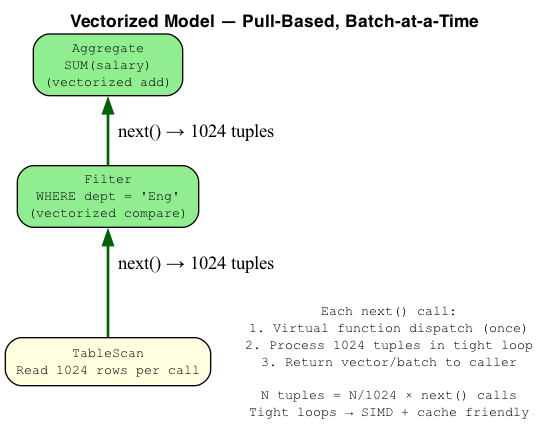

In [4]:
path = render_vectorized_model(
    operators=[
        {"name": "TableScan", "description": "Read 1024 rows per call", "color": "lightyellow"},
        {"name": "Filter", "description": "WHERE dept = 'Eng'\n(vectorized compare)", "color": "lightgreen"},
        {"name": "Aggregate", "description": "SUM(salary)\n(vectorized add)", "color": "lightgreen"},
    ],
    batch_size=1024,
    filename="vectorized", output_dir=OUTPUT_DIR,
)
if path.endswith(".png"):
    display(Image(filename=path))

In [5]:
# Implement vectorized execution

BATCH_SIZE = 1024

class VecScan:
    def __init__(self, data: dict):
        self.data = data
        self.n_rows = len(next(iter(data.values())))
        self.pos = 0
        self.calls = 0
    
    def next_batch(self):
        self.calls += 1
        if self.pos >= self.n_rows:
            return None
        end = min(self.pos + BATCH_SIZE, self.n_rows)
        batch = {col: self.data[col][self.pos:end] for col in self.data}
        self.pos = end
        return batch

class VecFilter:
    def __init__(self, child, column: str, value):
        self.child = child
        self.column = column
        self.value = value
        self.calls = 0
    
    def next_batch(self):
        self.calls += 1
        batch = self.child.next_batch()
        if batch is None:
            return None
        # Vectorized filter: tight loop over entire batch
        mask = [batch[self.column][i] == self.value for i in range(len(batch[self.column]))]
        return {col: [batch[col][i] for i, m in enumerate(mask) if m] for col in batch}

class VecAggregate:
    def __init__(self, child, column: str):
        self.child = child
        self.column = column
        self.calls = 0
    
    def next_batch(self):
        self.calls += 1
        total = 0
        count = 0
        while True:
            batch = self.child.next_batch()
            if batch is None:
                return {"sum": total, "count": count} if count > 0 else None
            total += sum(batch[self.column])  # vectorized sum over batch
            count += len(batch[self.column])

# Run the same query
scan = VecScan(data)
filt = VecFilter(scan, "department", "Engineering")
agg = VecAggregate(filt, "salary")

start = time.time()
result = agg.next_batch()
vec_time = time.time() - start

print(f"Result: SUM={result['sum']:,}, COUNT={result['count']:,}")
print(f"Time: {vec_time:.3f}s (vs iterator: {iterator_time:.3f}s) → {iterator_time/vec_time:.1f}x faster")
print(f"\nFunction calls:")
print(f"  Scan.next_batch():      {scan.calls:>8,}  (vs {N:,} for iterator)")
print(f"  Filter.next_batch():    {filt.calls:>8,}")
print(f"  Aggregate.next_batch(): {agg.calls:>8,}")
total_calls = scan.calls + filt.calls + agg.calls
print(f"  Total:                  {total_calls:>8,}")
print(f"\n→ {total_calls:,} function calls vs {N + N + 1:,} for iterator.")
print(f"→ {(N + N + 1) // total_calls}x fewer function calls.")
print(f"→ Each call processes {BATCH_SIZE} tuples in a tight loop — much better for CPU.")

Result: SUM=25,027,727,296, COUNT=200,387
Time: 0.116s (vs iterator: 0.270s) → 2.3x faster

Function calls:
  Scan.next_batch():           978  (vs 1,000,000 for iterator)
  Filter.next_batch():         978
  Aggregate.next_batch():        1
  Total:                     1,957

→ 1,957 function calls vs 2,000,001 for iterator.
→ 1021x fewer function calls.
→ Each call processes 1024 tuples in a tight loop — much better for CPU.


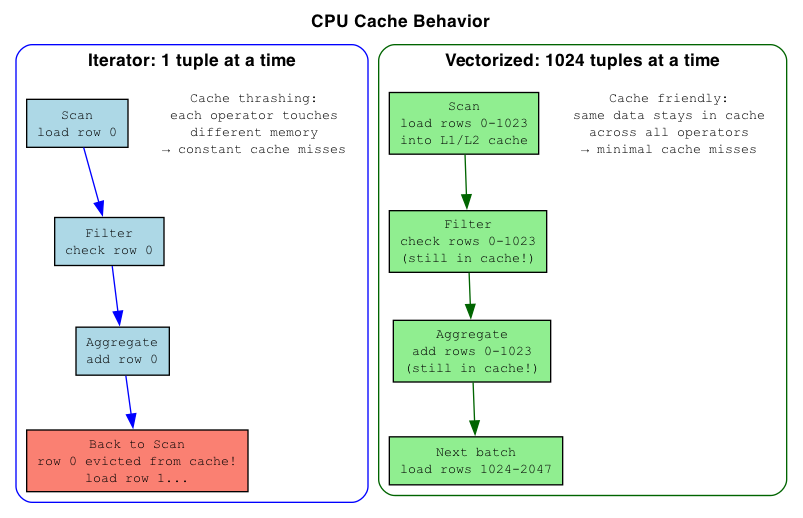

Why vectorized is faster — it's not just fewer function calls:

1. CACHE LOCALITY: a batch of 1024 ints = 8KB. Fits in L1 cache (32-64KB).
   All three operators process the SAME 8KB before moving on.
   Iterator: each operator touches different memory → constant cache misses.

2. SIMD: a tight loop over 1024 ints can use AVX2/AVX-512 instructions.
   Process 8-16 integers per CPU cycle instead of 1.
   Iterator: 1 tuple per call → SIMD impossible.

3. BRANCH PREDICTION: tight loop = predictable branch pattern.
   CPU pipeline stays full. Iterator: unpredictable virtual dispatch.


In [6]:
# Show CPU cache behavior difference
path = render_cache_behavior(filename="cache", output_dir=OUTPUT_DIR)
if path.endswith(".png"):
    display(Image(filename=path))

print("Why vectorized is faster — it's not just fewer function calls:")
print()
print("1. CACHE LOCALITY: a batch of 1024 ints = 8KB. Fits in L1 cache (32-64KB).")
print("   All three operators process the SAME 8KB before moving on.")
print("   Iterator: each operator touches different memory → constant cache misses.")
print()
print("2. SIMD: a tight loop over 1024 ints can use AVX2/AVX-512 instructions.")
print("   Process 8-16 integers per CPU cycle instead of 1.")
print("   Iterator: 1 tuple per call → SIMD impossible.")
print()
print("3. BRANCH PREDICTION: tight loop = predictable branch pattern.")
print("   CPU pipeline stays full. Iterator: unpredictable virtual dispatch.")

In [7]:
# Prove SIMD advantage with numpy (which uses SIMD under the hood)

# Pure Python sum (simulates iterator)
salary_list = data["salary"]
dept_list = data["department"]

start = time.time()
total = 0
for i in range(N):
    if dept_list[i] == "Engineering":
        total += salary_list[i]
python_time = time.time() - start

# NumPy vectorized (uses SIMD)
salary_arr = np.array(data["salary"])
dept_arr = np.array(data["department"])

start = time.time()
mask = dept_arr == "Engineering"
np_total = salary_arr[mask].sum()
numpy_time = time.time() - start

print(f"SUM(salary) WHERE dept='Engineering' on {N:,} rows:\n")
print(f"  Pure Python loop:  {python_time:.3f}s  (tuple-at-a-time)")
print(f"  NumPy vectorized:  {numpy_time:.3f}s  (SIMD + cache-friendly)")
print(f"  Speedup:           {python_time/numpy_time:.0f}x")
print(f"\n→ Same computation. NumPy is ~{python_time/numpy_time:.0f}x faster because it processes")
print(f"  arrays in tight C loops with SIMD instructions.")
print(f"→ This is exactly what vectorized engines (DuckDB, Velox) do internally.")

SUM(salary) WHERE dept='Engineering' on 1,000,000 rows:

  Pure Python loop:  0.055s  (tuple-at-a-time)
  NumPy vectorized:  0.006s  (SIMD + cache-friendly)
  Speedup:           9x

→ Same computation. NumPy is ~9x faster because it processes
  arrays in tight C loops with SIMD instructions.
→ This is exactly what vectorized engines (DuckDB, Velox) do internally.


---
## Part 3: JIT Compilation

Introduced by Thomas Neumann's HyPer system (TU Munich, 2011). Used by Spark (Tungsten/Whole-Stage CodeGen), Umbra, NoisePage.

Instead of interpreting the query plan at runtime, **generate native code** for each query:

1. Parse SQL → query plan
2. **Compile** the plan into a tight loop (using LLVM or bytecode generation)
3. Execute the compiled code directly

Key differences from vectorized:
- **Push-based** (not pull): data flows down through operators, no `next()` calls at all
- **Fused pipeline**: scan + filter + aggregate become ONE loop body
- **No virtual dispatch**: operators are inlined into the generated code
- **No materialization**: intermediate results stay in CPU registers, never written to memory

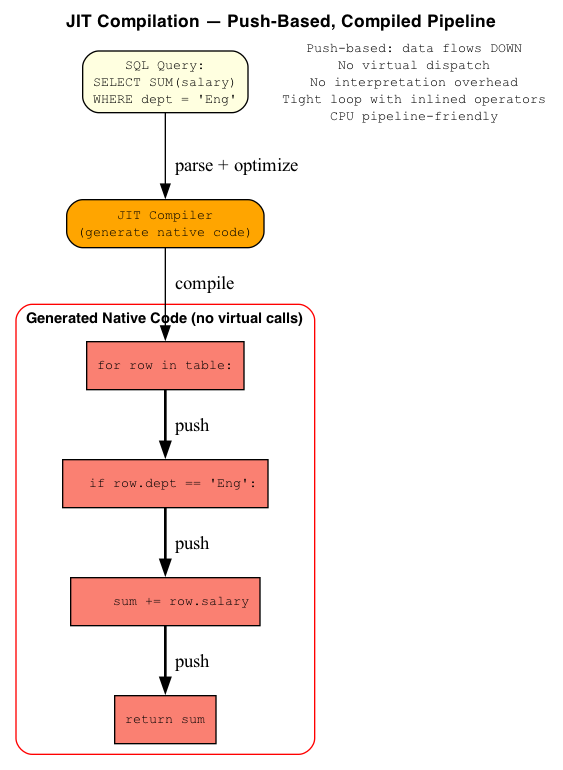

The JIT-compiled query is essentially:

  // Generated C code (compiled to machine code via LLVM)
  int64_t sum = 0;
  for (int i = 0; i < n_rows; i++) {
    if (dept[i] == ENGINEERING) {  // no virtual dispatch
      sum += salary[i];            // stays in register
    }
  }
  return sum;

→ No operator boundaries. No function calls. No materialization.
→ The compiler can optimize this like any C loop: unroll, vectorize, pipeline.


In [8]:
path = render_jit_model(
    query="SELECT SUM(salary)\nWHERE dept = 'Eng'",
    pipeline_stages=[
        "for row in table:",
        "  if row.dept == 'Eng':",
        "    sum += row.salary",
        "return sum",
    ],
    filename="jit", output_dir=OUTPUT_DIR,
)
if path.endswith(".png"):
    display(Image(filename=path))

print("The JIT-compiled query is essentially:")
print()
print("  // Generated C code (compiled to machine code via LLVM)")
print("  int64_t sum = 0;")
print("  for (int i = 0; i < n_rows; i++) {")
print("    if (dept[i] == ENGINEERING) {  // no virtual dispatch")
print("      sum += salary[i];            // stays in register")
print("    }")
print("  }")
print("  return sum;")
print()
print("→ No operator boundaries. No function calls. No materialization.")
print("→ The compiler can optimize this like any C loop: unroll, vectorize, pipeline.")

In [9]:
# Simulate JIT-compiled execution (hand-written tight loop)

# This is what JIT-compiled code looks like after compilation
start = time.time()
jit_sum = 0
jit_count = 0
sal = data["salary"]
dep = data["department"]
target = "Engineering"
for i in range(N):
    if dep[i] == target:
        jit_sum += sal[i]
        jit_count += 1
jit_time = time.time() - start

print(f"Result: SUM={jit_sum:,}, COUNT={jit_count:,}")
print(f"\nExecution times:")
print(f"  Iterator (Volcano):  {iterator_time:.3f}s")
print(f"  Vectorized (Python): {vec_time:.3f}s")
print(f"  JIT-style (fused):   {jit_time:.3f}s")
print(f"  NumPy (true SIMD):   {numpy_time:.3f}s")
print(f"\n→ The fused loop is faster than iterator because there's no operator overhead.")
print(f"→ In a real JIT engine (HyPer, Spark Tungsten), this loop would be compiled to")
print(f"  native machine code via LLVM, approaching numpy-level performance.")
print(f"→ Python can't show the full JIT advantage because Python itself is interpreted.")

Result: SUM=25,027,727,296, COUNT=200,387

Execution times:
  Iterator (Volcano):  0.270s
  Vectorized (Python): 0.116s
  JIT-style (fused):   0.063s
  NumPy (true SIMD):   0.006s

→ The fused loop is faster than iterator because there's no operator overhead.
→ In a real JIT engine (HyPer, Spark Tungsten), this loop would be compiled to
  native machine code via LLVM, approaching numpy-level performance.
→ Python can't show the full JIT advantage because Python itself is interpreted.


---
## Part 4: Side-by-Side Comparison

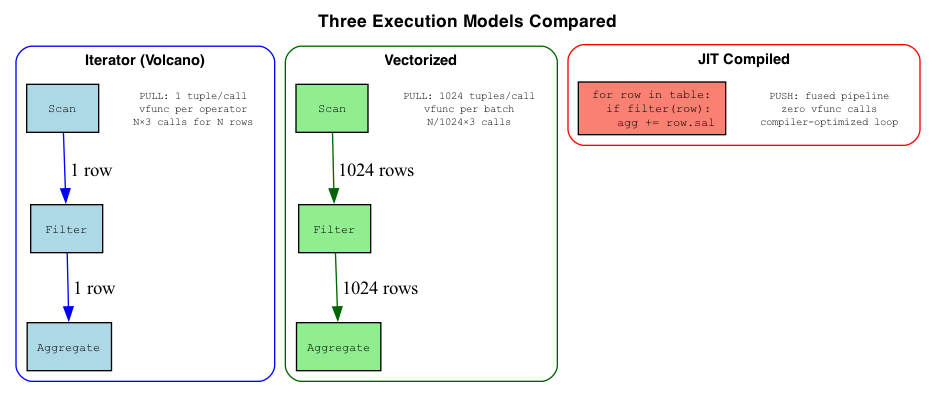

In [10]:
path = render_three_models_comparison(filename="comparison", output_dir=OUTPUT_DIR)
if path.endswith(".png"):
    display(Image(filename=path))

In [11]:
# Benchmark across data sizes
sizes = [100_000, 500_000, 1_000_000, 5_000_000]
iter_times = []
vec_times = []
jit_times = []
np_times = []

for n in sizes:
    random.seed(42)
    d = {
        "department": [random.choice(departments) for _ in range(n)],
        "salary": [random.randint(50000, 200000) for _ in range(n)],
    }
    
    # Iterator
    scan = ScanOperator(d)
    filt = FilterOperator(scan, "department", "Engineering")
    agg = AggregateOperator(filt, "salary")
    start = time.time()
    agg.next()
    iter_times.append(time.time() - start)
    
    # Vectorized
    scan = VecScan(d)
    filt = VecFilter(scan, "department", "Engineering")
    agg = VecAggregate(filt, "salary")
    start = time.time()
    agg.next_batch()
    vec_times.append(time.time() - start)
    
    # JIT-style fused loop
    sal = d["salary"]
    dep = d["department"]
    start = time.time()
    s = 0
    for i in range(n):
        if dep[i] == "Engineering":
            s += sal[i]
    jit_times.append(time.time() - start)
    
    # NumPy SIMD
    sa = np.array(d["salary"])
    da = np.array(d["department"])
    start = time.time()
    sa[da == "Engineering"].sum()
    np_times.append(time.time() - start)

# Print results
print(f"{'Rows':>10} {'Iterator':>10} {'Vectorized':>12} {'Fused Loop':>12} {'NumPy/SIMD':>12}")
print("-" * 60)
for i, n in enumerate(sizes):
    print(f"{n:>10,} {iter_times[i]:>8.3f}s {vec_times[i]:>10.3f}s "
          f"{jit_times[i]:>10.3f}s {np_times[i]:>10.3f}s")

      Rows   Iterator   Vectorized   Fused Loop   NumPy/SIMD
------------------------------------------------------------
   100,000    0.023s      0.009s      0.005s      0.001s
   500,000    0.118s      0.046s      0.028s      0.003s
 1,000,000    0.235s      0.092s      0.055s      0.006s
 5,000,000    1.173s      0.450s      0.269s      0.030s


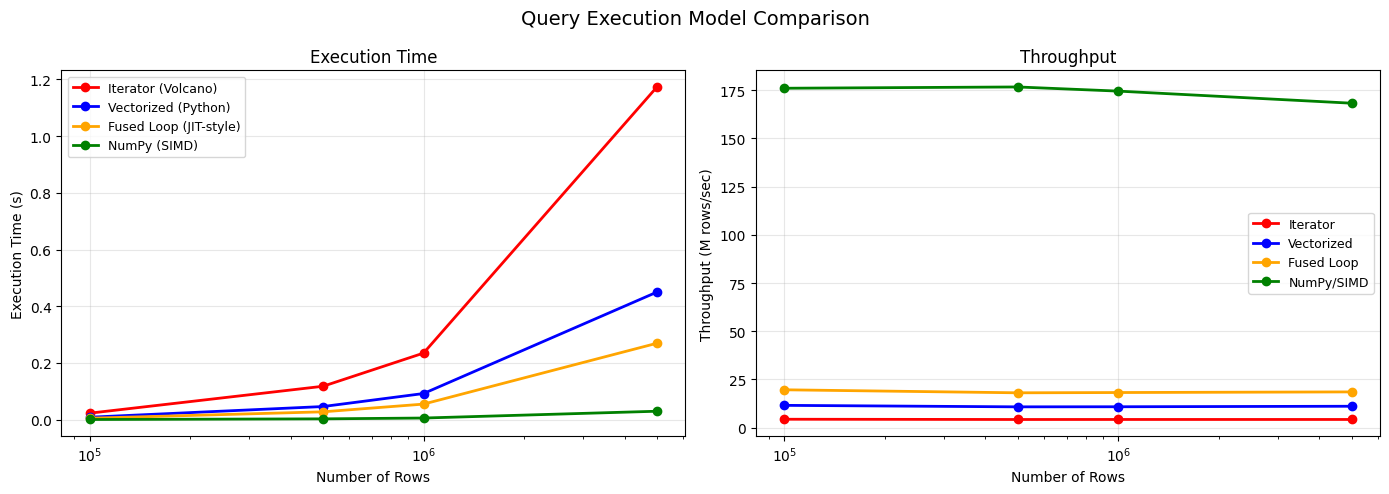

→ Iterator is slowest: function call overhead per tuple dominates.
→ Vectorized amortizes the overhead across batches.
→ Fused loop eliminates operator boundaries entirely.
→ NumPy/SIMD shows what's possible with true hardware vectorization.


In [12]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute times
ax1.plot(sizes, iter_times, 'o-', color='red', linewidth=2, label='Iterator (Volcano)')
ax1.plot(sizes, vec_times, 'o-', color='blue', linewidth=2, label='Vectorized (Python)')
ax1.plot(sizes, jit_times, 'o-', color='orange', linewidth=2, label='Fused Loop (JIT-style)')
ax1.plot(sizes, np_times, 'o-', color='green', linewidth=2, label='NumPy (SIMD)')
ax1.set_xlabel('Number of Rows')
ax1.set_ylabel('Execution Time (s)')
ax1.set_title('Execution Time')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Throughput
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, iter_times)], 'o-', color='red', linewidth=2, label='Iterator')
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, vec_times)], 'o-', color='blue', linewidth=2, label='Vectorized')
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, jit_times)], 'o-', color='orange', linewidth=2, label='Fused Loop')
ax2.plot(sizes, [n/t/1e6 for n, t in zip(sizes, np_times)], 'o-', color='green', linewidth=2, label='NumPy/SIMD')
ax2.set_xlabel('Number of Rows')
ax2.set_ylabel('Throughput (M rows/sec)')
ax2.set_title('Throughput')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.suptitle('Query Execution Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=150)
plt.show()

print("→ Iterator is slowest: function call overhead per tuple dominates.")
print("→ Vectorized amortizes the overhead across batches.")
print("→ Fused loop eliminates operator boundaries entirely.")
print("→ NumPy/SIMD shows what's possible with true hardware vectorization.")

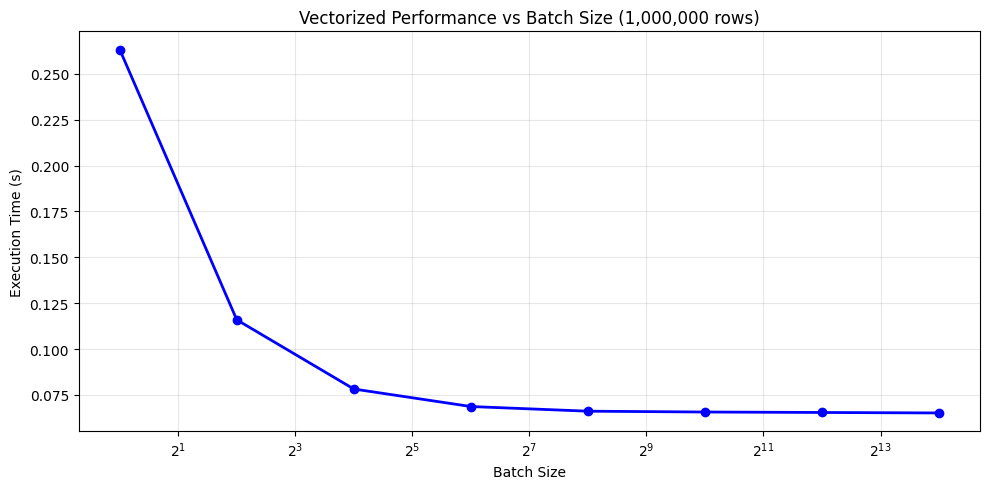

→ Batch size 1 = iterator model (worst). Performance improves rapidly up to ~1024.
→ Beyond ~1024, gains plateau — the batch exceeds L1 cache size.
→ Sweet spot: 1024-4096. This is why DuckDB/Velox use 1024-2048 as default.
→ Too large = cache thrashing. Too small = function call overhead.


In [13]:
# Batch size sensitivity: how does vector size affect performance?
batch_sizes_test = [1, 4, 16, 64, 256, 1024, 4096, 16384]
batch_times = []

for bs in batch_sizes_test:
    old_bs = BATCH_SIZE
    # Inline a quick test
    d = {"department": data["department"], "salary": data["salary"]}
    pos = 0
    total = 0
    n = len(d["salary"])
    start = time.time()
    while pos < n:
        end = min(pos + bs, n)
        for i in range(pos, end):
            if d["department"][i] == "Engineering":
                total += d["salary"][i]
        pos = end
    batch_times.append(time.time() - start)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(batch_sizes_test, batch_times, 'o-', color='blue', linewidth=2)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Execution Time (s)')
ax.set_title(f'Vectorized Performance vs Batch Size ({N:,} rows)')
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/batch_size.png', dpi=150)
plt.show()

print("→ Batch size 1 = iterator model (worst). Performance improves rapidly up to ~1024.")
print("→ Beyond ~1024, gains plateau — the batch exceeds L1 cache size.")
print("→ Sweet spot: 1024-4096. This is why DuckDB/Velox use 1024-2048 as default.")
print("→ Too large = cache thrashing. Too small = function call overhead.")

---
## Part 5: When to Use Which — Production Tradeoffs

### The tradeoff triangle

| Dimension | Iterator | Vectorized | JIT |
|-----------|----------|-----------|-----|
| **Implementation complexity** | Simple | Medium | High (needs LLVM or codegen) |
| **Compilation latency** | Zero | Zero | High (100ms+ to compile) |
| **Throughput** | Low | High | Highest |
| **Adaptivity** | High (easy to add operators) | Medium | Low (must re-compile) |
| **Debug-ability** | Easy (step through) | Medium | Hard (generated code) |

### What real systems use

| System | Model | Why |
|--------|-------|-----|
| PostgreSQL | Iterator | Simplicity, extensibility, decades of operators |
| SQLite | Iterator | Bytecode VM (similar to iterator, slightly faster) |
| DuckDB | Vectorized | Analytical workloads, SIMD-optimized, no compile latency |
| Snowflake | Vectorized | Cloud analytics, predictable performance |
| ClickHouse | Vectorized | High-throughput analytics |
| Velox (Meta) | Vectorized | General-purpose engine for Presto/Spark |
| Spark (Tungsten) | JIT (Whole-Stage CodeGen) | Long-running queries amortize compile cost |
| HyPer/Umbra | JIT (LLVM) | Academic state-of-the-art, highest throughput |
| DataFusion | Vectorized + JIT | Hybrid: vectorized by default, JIT for hot paths |

### The emerging consensus

Modern systems increasingly use **vectorized as the default** with optional JIT:
- Vectorized gives 80% of JIT's performance with zero compile latency
- JIT compilation takes 100ms-1s — unacceptable for short queries
- For long-running queries, JIT can be applied selectively to hot loops
- Adaptive: start vectorized, JIT-compile if the query runs long enough

This is similar to how JVMs (Java) and V8 (JavaScript) work:
interpret first, JIT-compile hot paths.

### The mental model

```
Iterator:    "Interpret the query plan, one tuple at a time"
             Simple. Slow. Universal.

Vectorized:  "Interpret the query plan, one BATCH at a time"
             Same architecture as iterator, but hardware-friendly.
             The MonetDB/X100 insight: amortize overhead across batches.

JIT:         "Compile the query plan into native code, then run it"
             Eliminate ALL interpretation overhead.
             The HyPer insight: queries are programs — compile them.
```

In [14]:
import glob
print("Lab complete! Output files:")
total = 0
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        fpath = os.path.join(root, f)
        size = os.path.getsize(fpath)
        total += size
file_count = sum(len(files) for _, _, files in os.walk(OUTPUT_DIR))
print(f"  {file_count} files, {total:,} bytes total")
print(f"  All contained in {OUTPUT_DIR}/")

Lab complete! Output files:
  12 files, 356,449 bytes total
  All contained in _output/
